In [2]:
library(terra)
library(tidyverse)
library(sf)
library(hexbin)

terra 1.7.78

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks terra::extract()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE



In [3]:
library(ggspatial)  # For adding a geographic grid (optional)
library(sf)

In [4]:
library(viridis)
library(patchwork)
library(reshape2)

Loading required package: viridisLite


Attaching package: ‘patchwork’


The following object is masked from ‘package:terra’:

    area



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [89]:
theme_custom = list(
      theme_minimal() +
      theme(
          legend.position="top",
          legend.key.width=unit(2, "cm"),
          legend.key.height=unit(0.5, "cm"),
          legend.text=element_text(size=rel(1))
      ),
          annotation_scale(location = "br", style="ticks") ,
          #annotation_scale(location = "bl", style="box") ,
          annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal())
    )
guides_ht = list(
            guides(
                    fill=guide_colourbar(
                             #limits = c(0, 25), breaks=c(0,5,10,15,20,25),
                            #title=expression(atop(H30[HLS+Topo]~"2020","Vegetation height [m]")), 
                             title=paste0("2020 ","Vegetation height [m]"),
                            title.position = "top", label.position = "bottom", 
                            #keywidth = unit(.05, "cm"), keyheight = unit(.25, "cm"), nrow=1
                             )
          )
    )
guides_cc = list(
            guides(
                    fill=guide_colourbar(
                             #limits = c(0, 25), breaks=c(0,5,10,15,20,25),
                            #title=expression(atop(H30[HLS+Topo]~"2020","Vegetation height [m]")), 
                             title=paste0("Vegetation canopy cover [%]"),
                            title.position = "top", label.position = "bottom", 
                            #keywidth = unit(.05, "cm"), keyheight = unit(.25, "cm"), nrow=1
                             )
          )
    )

In [83]:
raster_read_proj_convert <- function(fn, STR='', SCALE=FALSE, SF=0.01){
    
    raster_proj <- rast(fn)    
    r <- project(raster_proj, "EPSG:4326")
    
    # # Check CRS and basic info
    # print(r)
    
    # Convert raster to data frame
    r_df <- as.data.frame(r, xy = TRUE)

    names(r_df) <- c('x','y',STR)

    if(SCALE){
        r_df[,c(STR)] = r_df[,c(STR)] * SF
        }

    # # Check the head
    # head(r_df)
    
    #r_df_long <- melt(r_df, id.vars = c("x", "y"), variable.name = "Band", value.name = "Value")
    #return (r_df_long)

    return (r_df)
    }

raster_hillshade <- function(dem_fn){

    # Read the DEM file
    # Replace "path/to/your/dem.tif" with the actual path to your DEM file
    dem <- rast(dem_fn)
    
    # Calculate slope and aspect (in radians)
    slope <- terrain(dem, "slope", unit="radians")
    aspect <- terrain(dem, "aspect", unit="radians")
    
    # Set parameters for hillshade calculation
    altitude <- 45  # Sun altitude angle in degrees
    azimuth <- 315  # Sun azimuth angle in degrees (315° = NW)
    azimuth_rad <- (90 - azimuth) * pi/180  # Convert to radians and adjust
    
    # Calculate hillshade
    ##hillshade <- shade(slope, aspect, altitude_rad, azimuth_rad)
    hillshade <- shade(slope, aspect, angle=45, direction=315, normalize=TRUE)
    # # Formula: cos(zenith) * cos(slope) + sin(zenith) * sin(slope) * cos(azimuth - aspect)
    # zenith_rad <- (90 - altitude) * pi/180
    # hillshade <- cos(zenith_rad) * cos(slope) + 
    #              sin(zenith_rad) * sin(slope) * cos(azimuth_rad - aspect)
    
    # # Scale the hillshade values to 0-255 for visualization
    # hillshade <- hillshade * 255

    # Define the target geographic CRS (WGS84)
    geo_crs <- "EPSG:4326"  # WGS84
  
    # Reproject hillshade to geographic coordinates
    hillshade_geo <- project(hillshade, geo_crs)

    # Convert raster to data frame
    r_df <- as.data.frame(hillshade_geo, xy = TRUE)
    names(r_df) <- c('x','y','shade')
    return(r_df)
    }

### Paths to data

In [28]:
CC_str = 'CC_gte_01p37m_30m'
s3_path = paste0('s3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_094195_',CC_str,'.tif')

In [84]:
df = raster_read_proj_convert(s3_path, STR='CC_gte_01p37m', SCALE=TRUE, SF=0.01)

In [86]:
max(df$CC_gte_01p37m)

[1] 78.70504

In [90]:
p_ht_mean = ggplot(df, aes(x = x, y = y, fill = `CC_gte_01p37m`)) +
          geom_raster() +
          scale_fill_viridis_c(name = "Value", option = "greens") +  # Continuous color bar
            annotate("text", x = Inf, y = Inf, label = "CC_gte_01p37m", hjust = 1.1, vjust = 1.5, size = 5) +
          coord_sf(crs = "EPSG:4326", expand = FALSE) +
          labs(x = "", y = "") +
          theme_custom +
          guides_cc

Warning message in viridisLite::viridis(n, alpha, begin, end, direction, option):
“Option 'greens' does not exist. Defaulting to 'viridis'.”


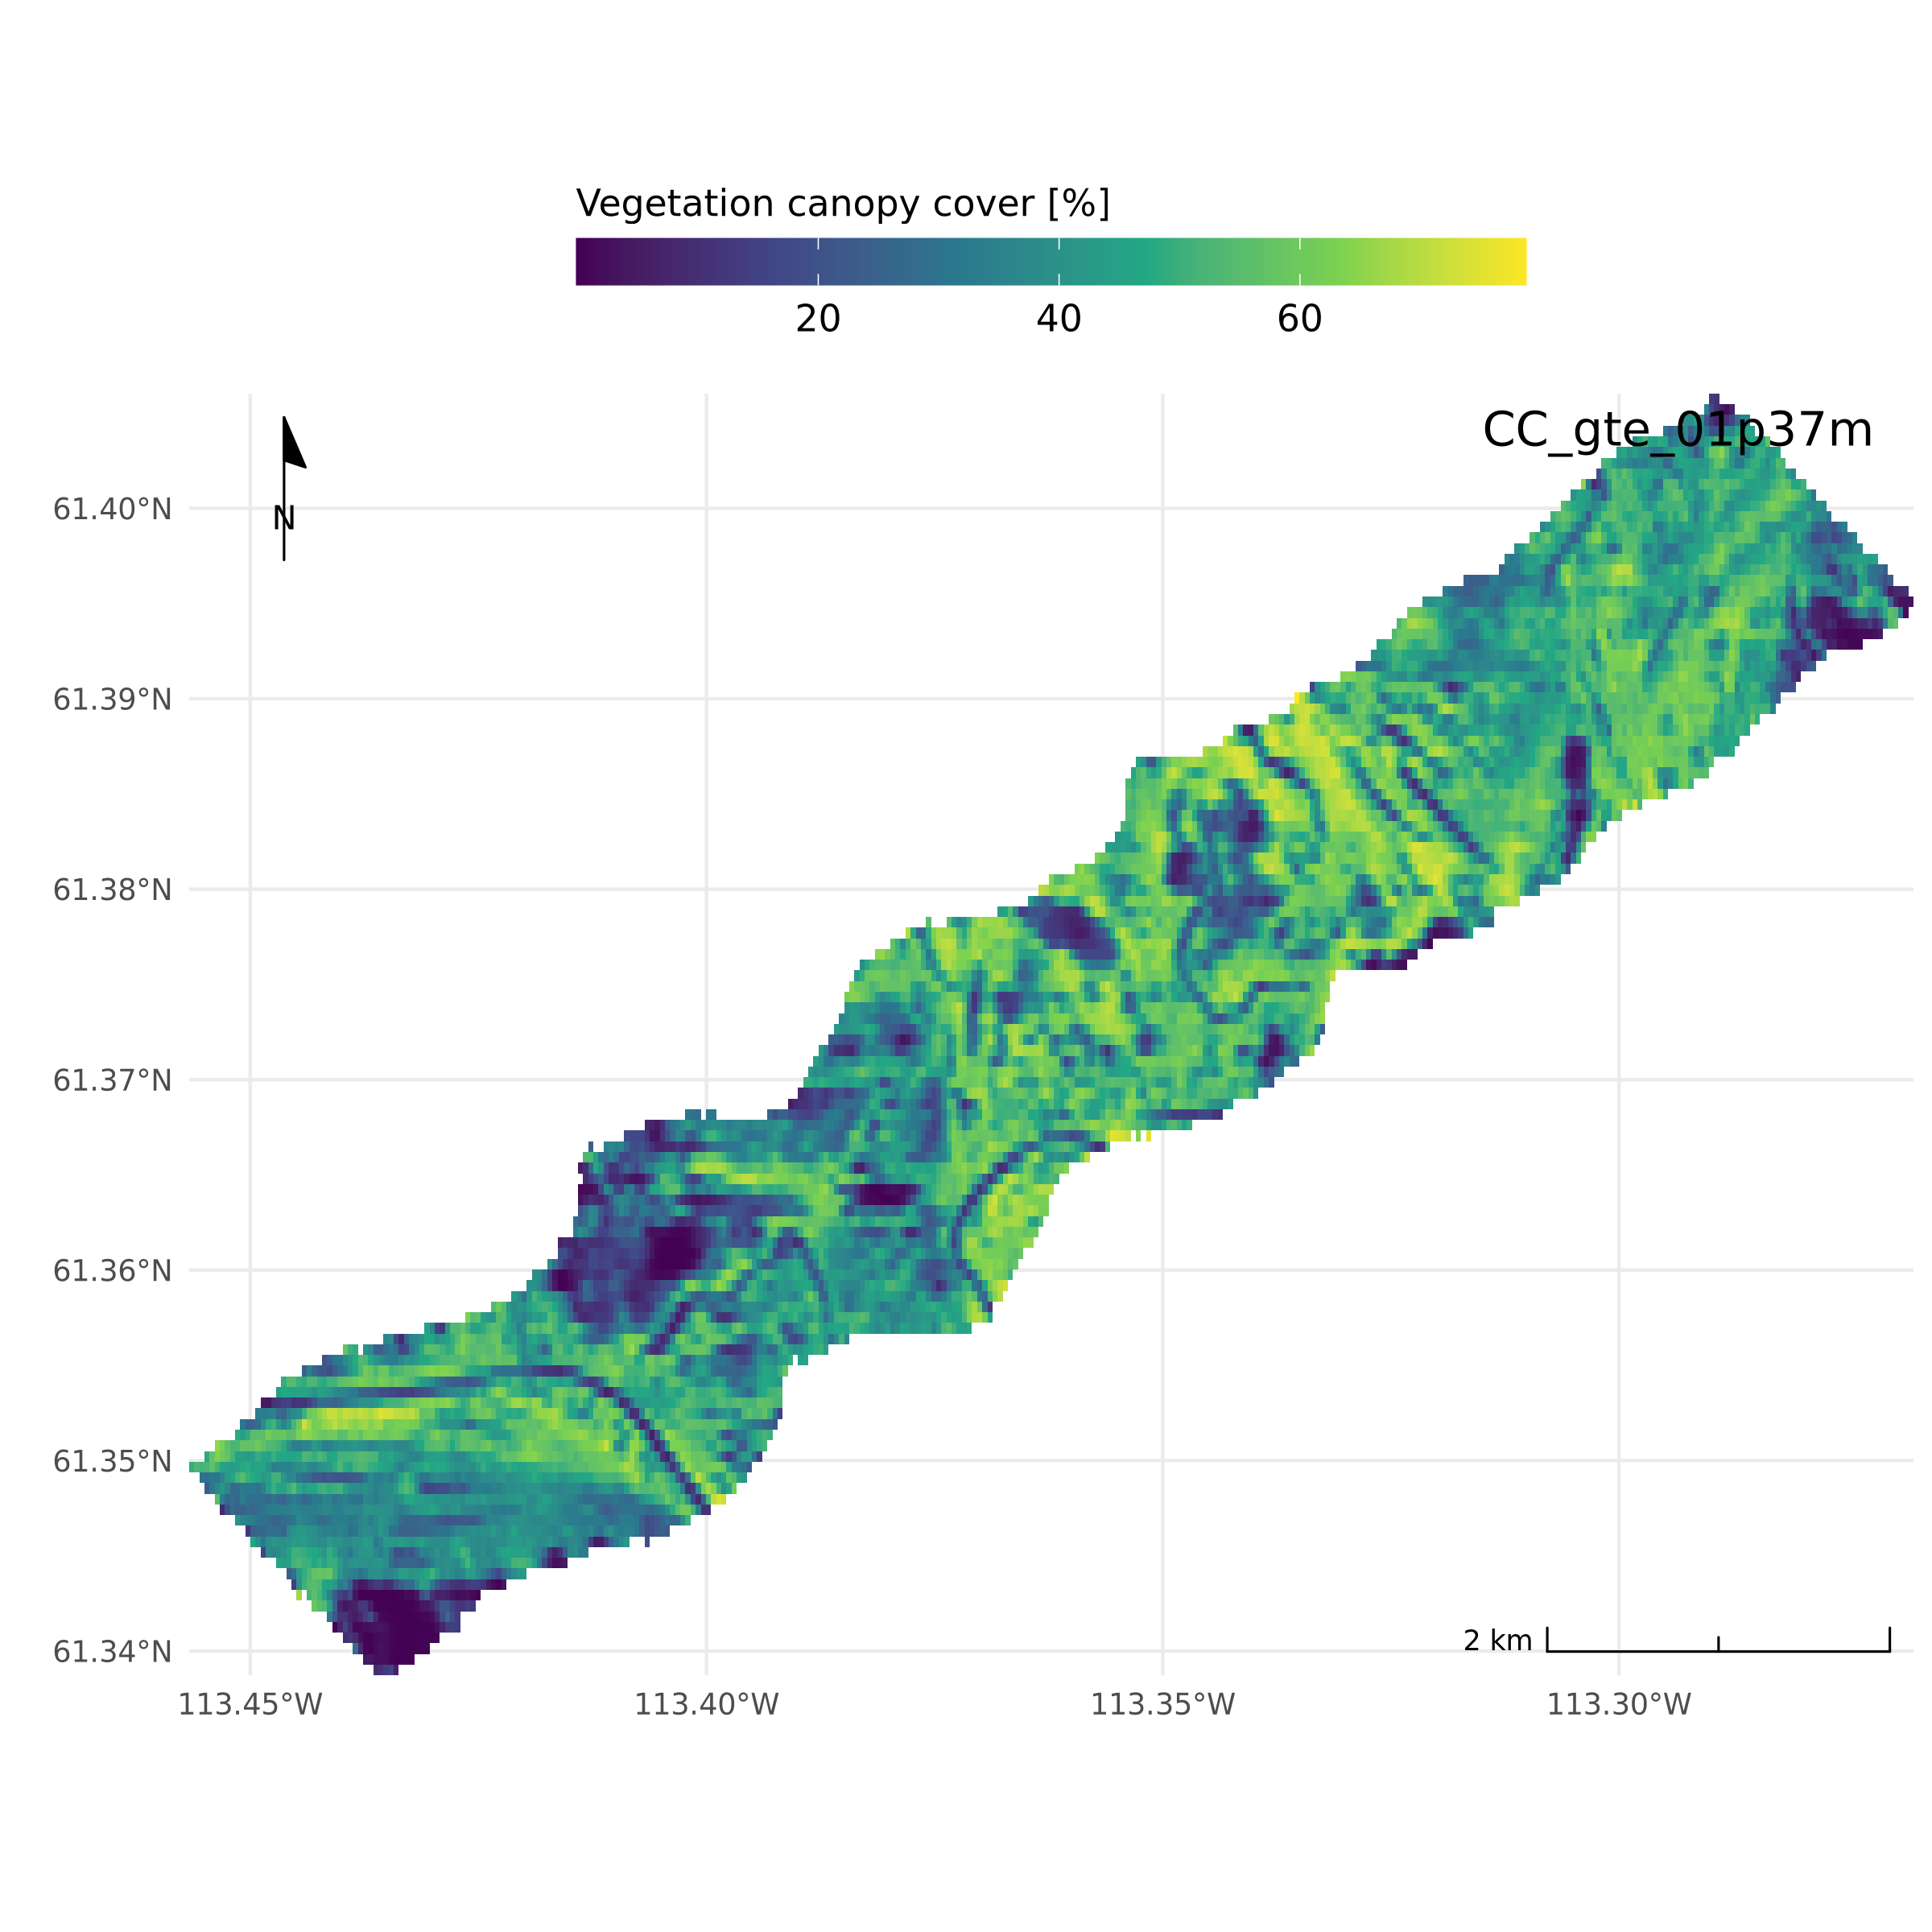

In [91]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 300)

p_ht_mean

In [57]:
ZG_str = 'ZG_mean_30m'
s3_path = paste0('s3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_094195_',CC_str,'.tif')

In [58]:
hs_df = raster_hillshade(s3_path)

In [59]:
head(hs_df)

,x,y,shade
,<dbl>,<dbl>,<dbl>
1952,-113.2899,61.40518,0.0000000
1953,-113.2893,61.40518,2.9239388
2354,-113.2916,61.40462,4.3737364
2355,-113.2910,61.40462,1.0054404
2356,-113.2904,61.40462,0.3376689
2357,-113.2899,61.40462,2.9540060


In [60]:
min(hs_df$shade)

[1] 0

Warning message in geom_raster(data = hs_df, mapping = aes(x = x, y = y, fill = shade), :
“Ignoring unknown parameters: `akpha`”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


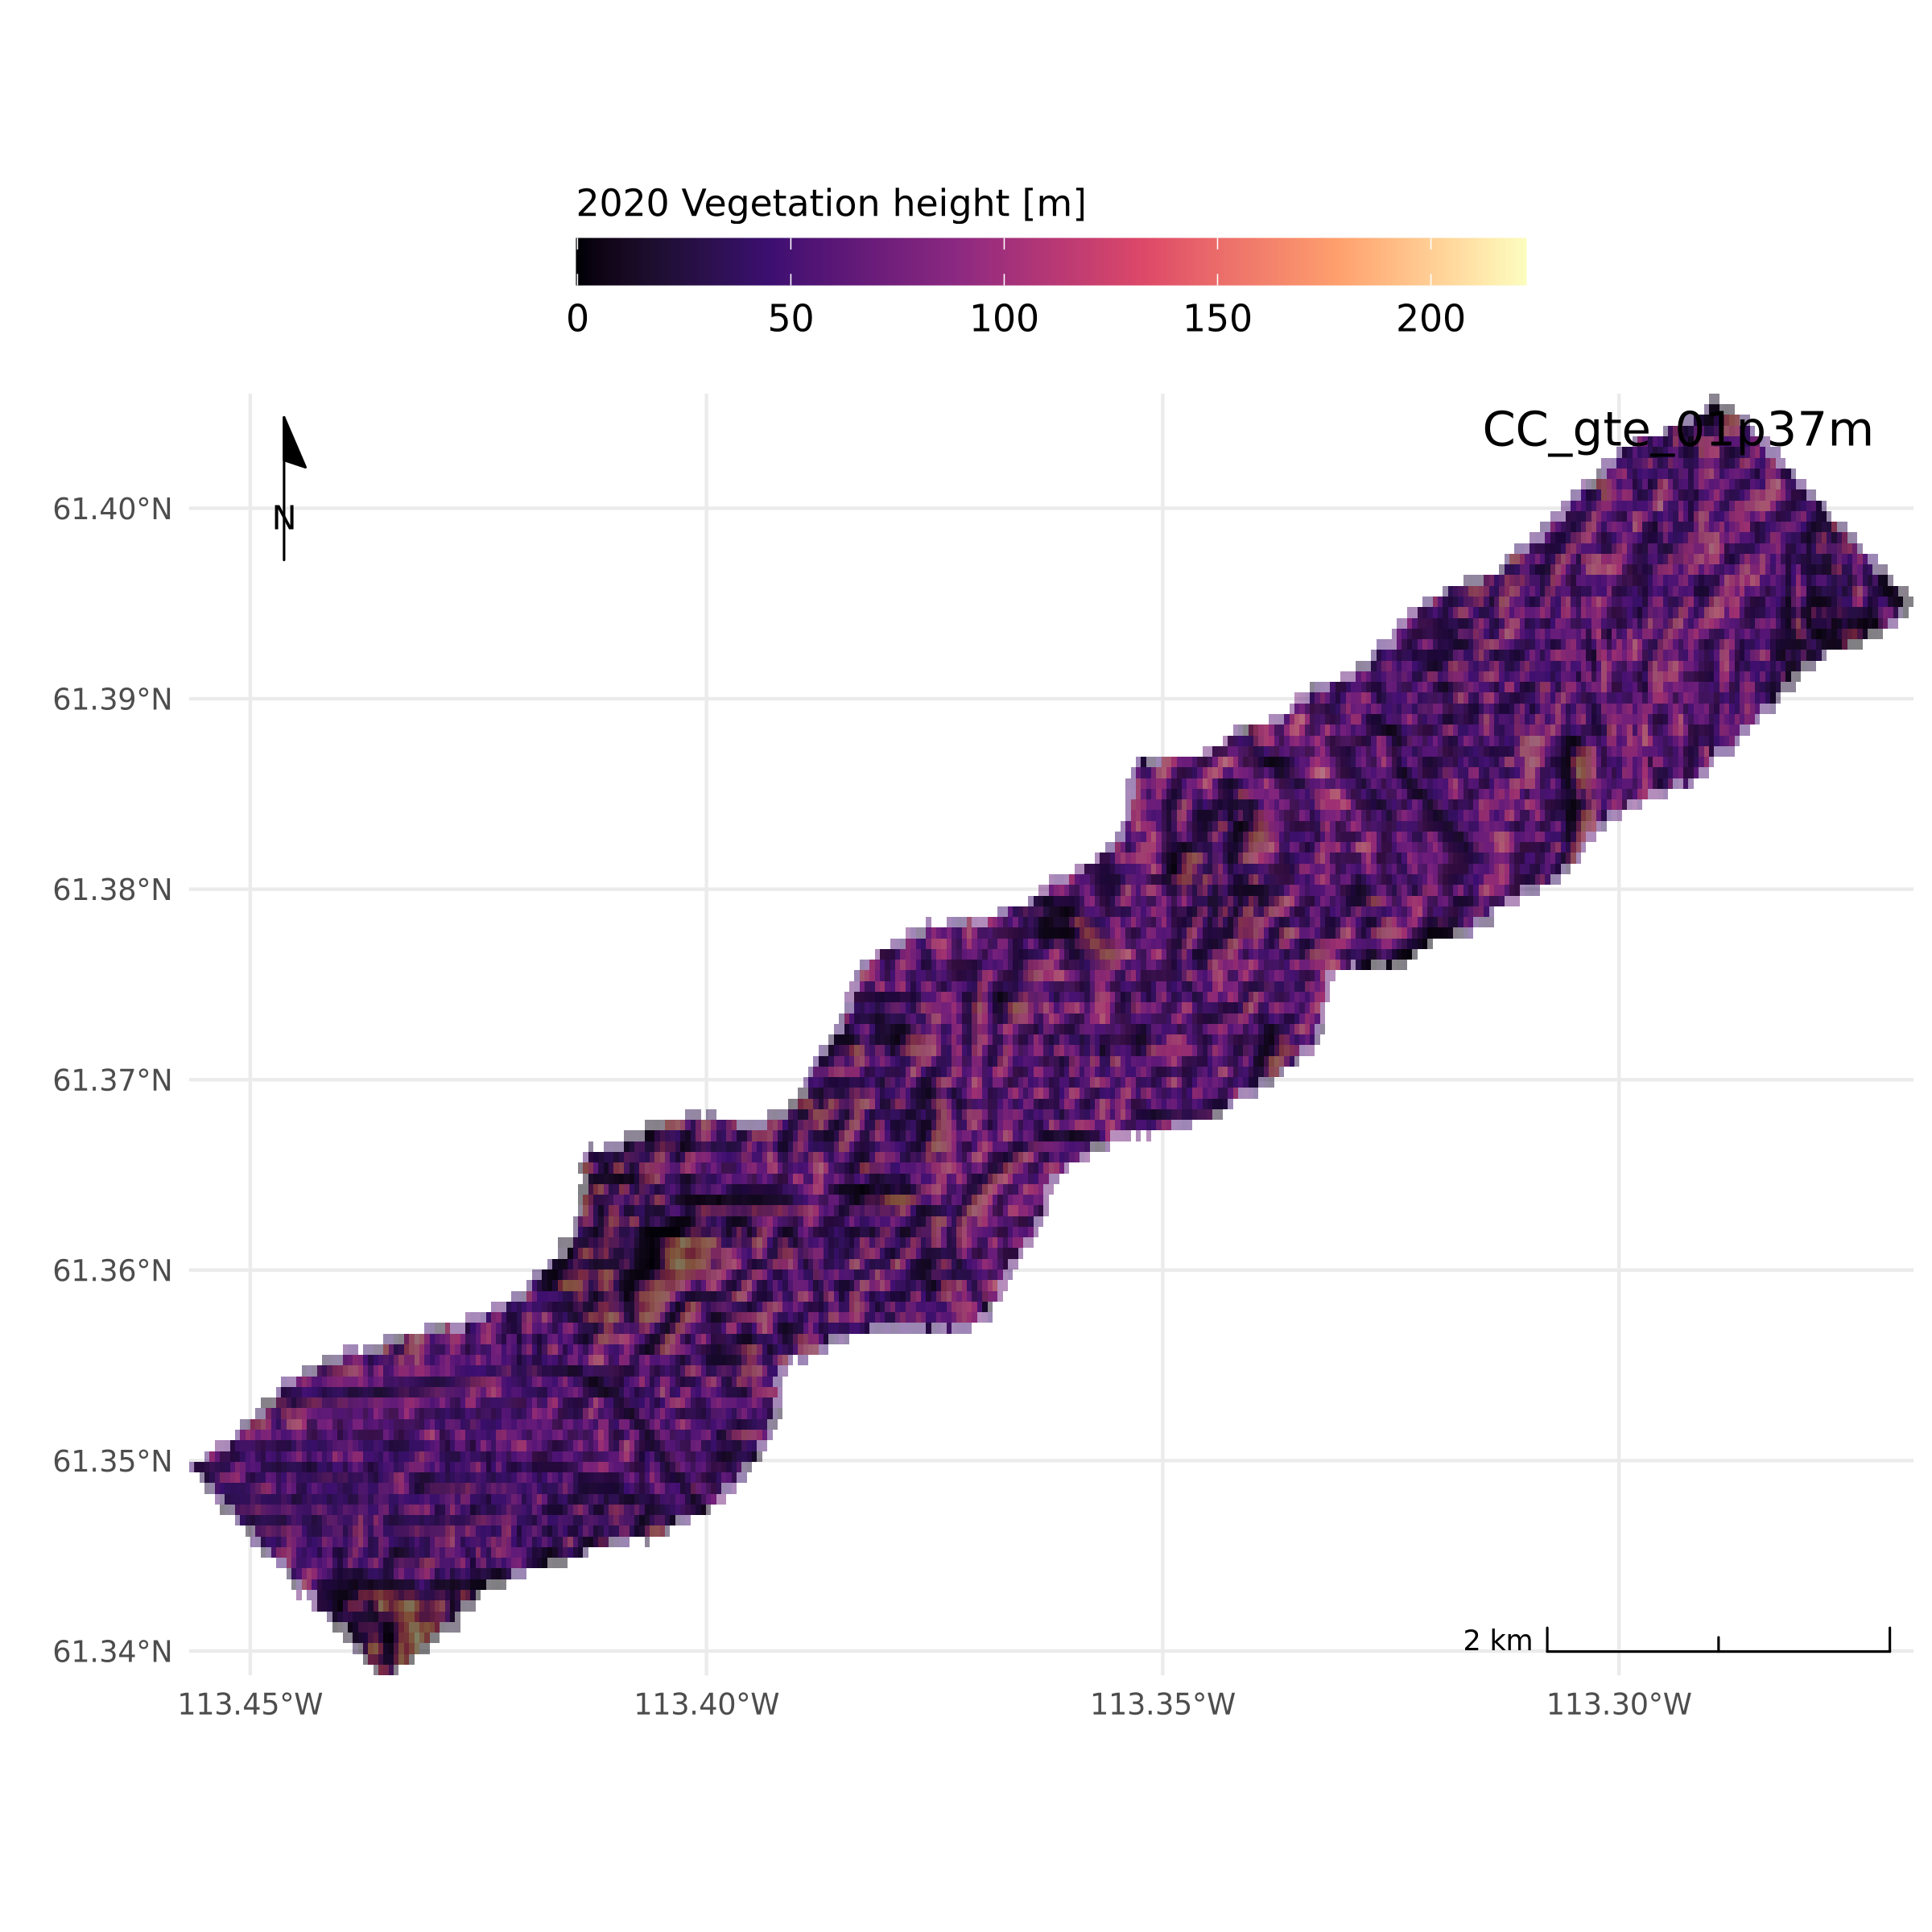

In [79]:
ggplot() +

# Add hillshade as grayscale background
geom_raster(data=hs_df, mapping=aes(x = x, y = y, fill = `shade`), akpha=0.5) +
scale_fill_gradient(low="black", high="white", guide="none") +
  # Add data
geom_raster(data=df, mapping=aes(x = x, y = y, fill = `CC_gte_01p37m`/100), alpha=0.5) +
scale_fill_viridis_c(name = "Value", option = "magma") +  # Continuous color bar
  # Add contour lines for additional elevation information
  #geom_contour(data=dem_df, mapping=aes(x=x, y=y, z=elevation), color="white", alpha=0.5, binwidth=100) +
annotate("text", x = Inf, y = Inf, label = "CC_gte_01p37m", hjust = 1.1, vjust = 1.5, size = 5) +
          coord_sf(crs = "EPSG:4326", expand = FALSE) +
          labs(x = "", y = "") +
          theme_custom +
          guides_ht